In [1]:
import transformers
import warnings
transformers.logging.set_verbosity_error()
warnings.filterwarnings("ignore")
from src.customFunctions import *
import pandas as pd
import pickle

In [21]:
eval = pd.read_json('/workspace/data/fiqa/eval_data.jsonl', lines=True)
collection_name="corpus"
corpusFile='/workspace/data/fiqa/corpus.jsonl'
colname='doc'
client=loadfileDB(collection_name=collection_name, filepath=corpusFile, colname=colname, chunk_size=1000)


Setting up Qdrant...
Collection already exists and has data. Skipping upload. 57638 points found.


# Naive RAG

In [3]:
def naiveRagEvaluation(eval_df,client,collection_name='corpus',colname='doc',k=3):
    metrics=[]
    for i,row in eval_df.iterrows():
        test_query=row['user_input']
        results=retrieveQueryEmbeddings(query_texts=test_query,client=client,collection_name=collection_name,colname=colname,k=k,verbose=False)
        llmResponse=llmRespose(query_results=results, test_query=test_query, colname=colname, verbose=False)
        metric=evaluate_answer(generated_answer=llmResponse, ground_truth=row['reference'], query_results=results, groundContext=row['retrieved_contexts'],colname=colname)
        metrics.append(metric)
        if (i+1)%10==0:
            print(f"Processed {i+1} / {len(eval_df)}")
    return pd.DataFrame(metrics)

In [3]:
with open('models/naiveRagResults.pkl', 'rb') as f:
    naiveRagResults = pickle.load(f)

In [ ]:
naiveRagResults=[None] * 5
for i in range(1,6):
    naiveRagResults[i-1]=naiveRagEvaluation(eval_df=eval,client=client,k=i)

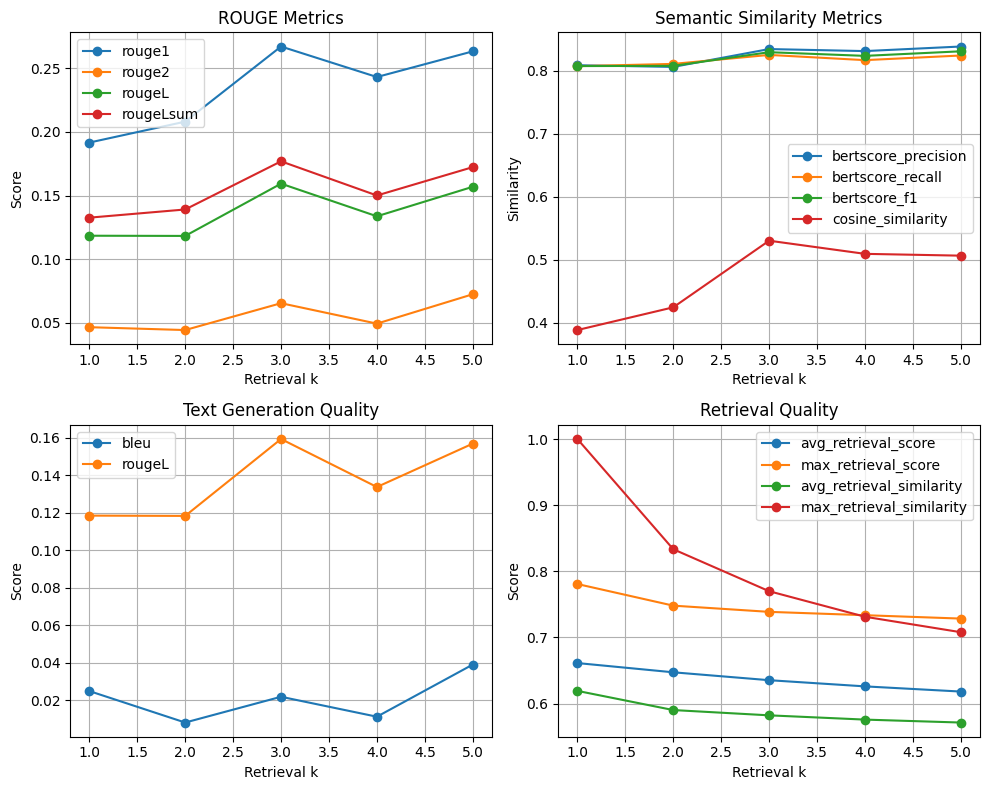

In [7]:
visualizeMetrics(naiveRagResults, paramValues=list(range(1, 6)), paramName='Retrieval k')

In [4]:
with open('models/naiveRagResults.pkl', 'wb') as f:
    pickle.dump(naiveRagResults, f)

# Advanced Retrieval: 

#### Reranking with Cross-Encoders

In [ ]:
def rerankRetrievalEval(eval_df,client,collection_name='corpus',colname='doc',k=3,rerank_k=20):
    from sentence_transformers import CrossEncoder
    import torch
    crossEncoder = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

    metrics=[]
    llmResponses=[]
    queryResults=[]
    for i,row in eval_df.iterrows():
        test_query=row['user_input']
        stage1Results=retrieveQueryEmbeddings(query_texts=test_query,client=client,collection_name=collection_name,colname=colname,k=rerank_k,verbose=False)
        pairs = []
        for point in stage1Results.points:
            doc_text = point.payload['doc'][0] if isinstance(point.payload['doc'], list) else point.payload['doc']
            pairs.append((test_query, doc_text))
        rerankScores = crossEncoder.predict(pairs, activation_fct=torch.nn.Sigmoid())
        for _, (point, rerankScore) in enumerate(zip(stage1Results.points, rerankScores)):
            point.score = 0.7 * rerankScore + 0.3 * point.score
        stage1Results.points.sort(key=lambda x: x.score, reverse=True)
        stage1Results.points = stage1Results.points[:k]
        llmResponse=llmRespose(query_results=stage1Results, test_query=test_query, colname=colname, verbose=False)
        metric=evaluate_answer(generated_answer=llmResponse, ground_truth=row['reference'], query_results=stage1Results, groundContext=row['retrieved_contexts'],colname=colname)
        metrics.append(metric)
        llmResponses.append(llmResponse)
        queryResults.append(stage1Results)
        if (i+1)%10==0:
            print(f"Processed {i+1} / {len(eval_df)}")
    return pd.DataFrame(metrics), llmResponses, queryResults

In [ ]:
with open('models/reRankingRagResults1.pkl', 'rb') as f:
    reRankingRagResults1 = pickle.load(f)

with open('models/reRankingRagllmResponse1.pkl', 'rb') as f:
    llmResponse1 = pickle.load(f)

with open('models/reRankingRagstage1Results1.pkl', 'rb') as f:
    stage1Results1 = pickle.load(f)

In [ ]:
llmResponse1=[None] * 5
stage1Results1=[None] * 5
reRankingRagResults1=[None] * 5
for i in range(1,6):
    reRankingRagResults1[i-1], llmResponse1[i-1], stage1Results1[i-1] = rerankRetrievalEval(eval_df=eval,client=client,k=i,rerank_k=20)

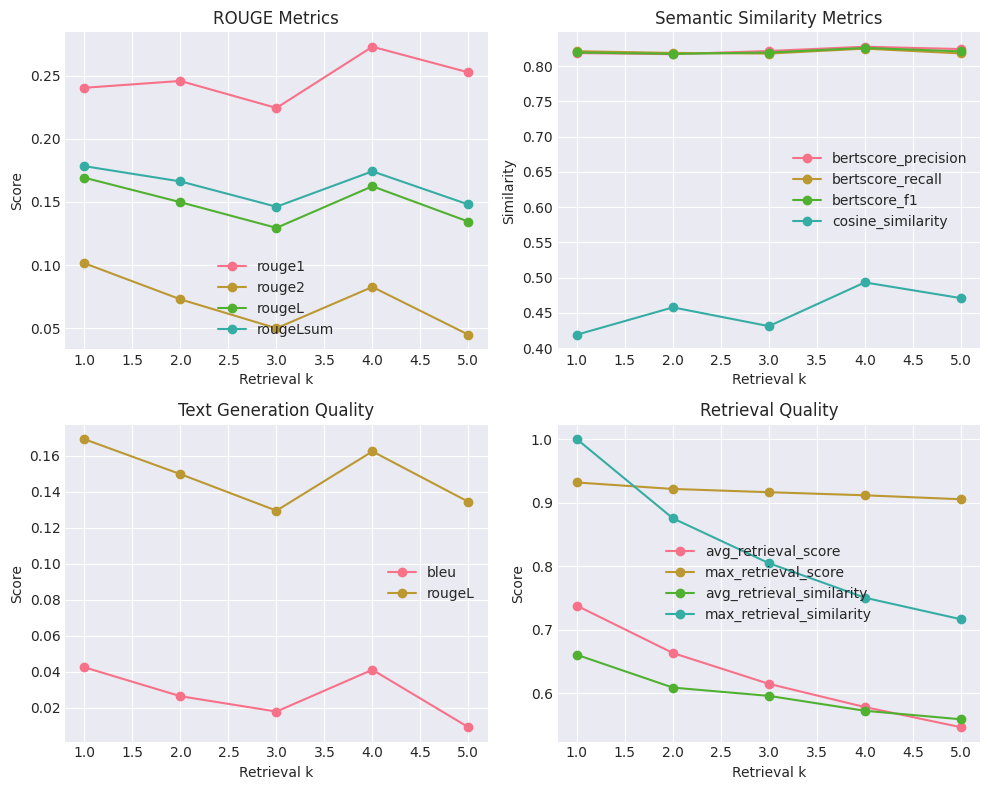

In [29]:
visualizeMetrics(reRankingRagResults1, paramValues=list(range(1, 6)), paramName='Retrieval k')

In [ ]:
with open('models/reRankingRagResults2.pkl', 'rb') as f:
    reRankingRagResults2 = pickle.load(f)

with open('models/reRankingRagllmResponse2.pkl', 'rb') as f:
    llmResponse2 = pickle.load(f)

with open('models/reRankingRagstage1Results2.pkl', 'rb') as f:
    stage1Results2 = pickle.load(f)

In [ ]:
llmResponse2=[None] * 5
stage1Results2=[None] * 5
reRankingRagResults2=[None] * 5
j=0
for i in range(10,35,5):
    reRankingRagResults2[j], llmResponse2[j], stage1Results2[j] = rerankRetrievalEval(eval_df=eval,client=client,k=4,rerank_k=i)
    j+=1

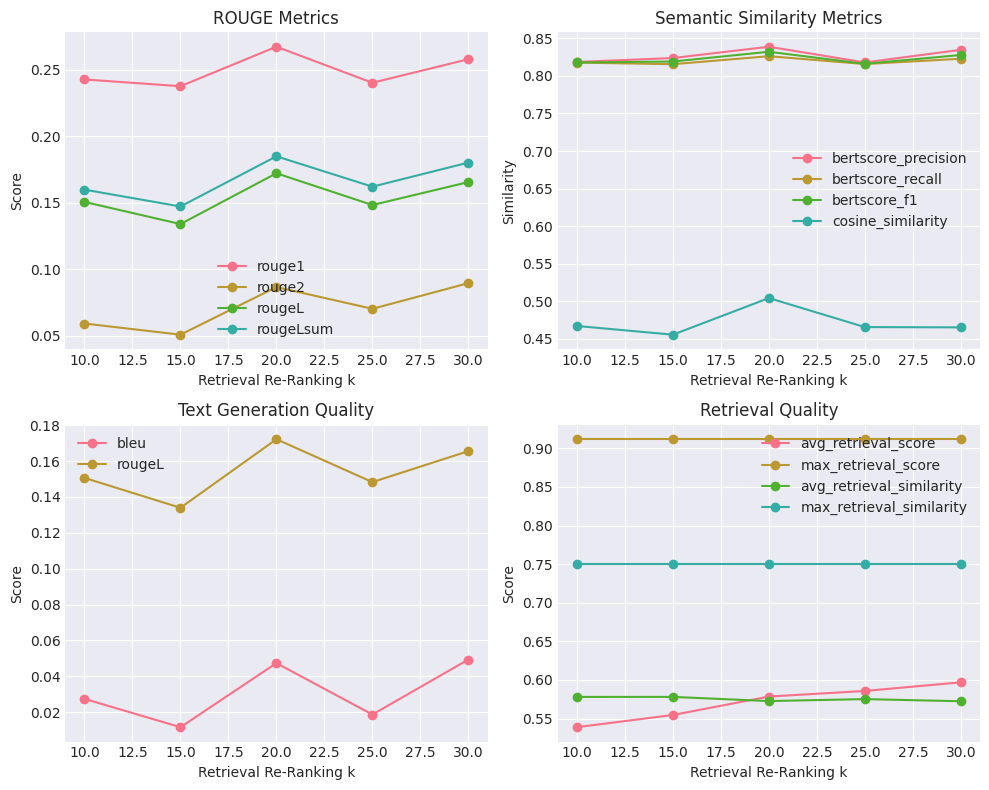

In [107]:
visualizeMetrics(reRankingRagResults2, paramValues=list(range(10,35,5)), paramName='Retrieval Re-Ranking k')

In [36]:
with open('models/reRankingRagResults1.pkl', 'wb') as f:
    pickle.dump(reRankingRagResults1, f)

with open('models/reRankingRagllmResponse1.pkl', 'wb') as f:
    pickle.dump(llmResponse1, f)

with open('models/reRankingRagstage1Results1.pkl', 'wb') as f:
    pickle.dump(stage1Results1, f)

with open('models/reRankingRagResults2.pkl', 'wb') as f:
    pickle.dump(reRankingRagResults2, f)

with open('models/reRankingRagllmResponse2.pkl', 'wb') as f:
    pickle.dump(llmResponse2, f)

with open('models/reRankingRagstage1Results2.pkl', 'wb') as f:
    pickle.dump(stage1Results2, f)

# Advanced Retrieval: 

#### Hypothetical Document Embeddings (HyDE)

In [15]:
def hydeRagEvaluation(eval_df,client,collection_name='corpus',colname='doc',k=3):
    import httpx
    metrics=[]
    for i,row in eval_df.iterrows():
        test_query=row['user_input']
        hydePrompt = f"""Based on the question, generate a hypothetical document that would answer it.
        
        Question: {test_query}
        
        Hypothetical document that answers this question:"""
        resp = httpx.post("http://localhost:8001/generate",json={"prompt": hydePrompt, "max_tokens": 100, "temperature": 0.3},timeout=120.0)
        hypotheticalDoc=""
        if resp.status_code == 200:
            hypotheticalDoc = resp.json()['text'].strip()
        if len(hypotheticalDoc)>10:
            hypotheticalDoc = hypotheticalDoc[len(hydePrompt):]
            results=retrieveQueryEmbeddings(query_texts=hypotheticalDoc,client=client,collection_name=collection_name,colname=colname,k=k,verbose=False)
        else:
            results=retrieveQueryEmbeddings(query_texts=test_query,client=client,collection_name=collection_name,colname=colname,k=k,verbose=False)
        
        llmResponse=llmRespose(query_results=results, test_query=test_query, colname=colname, verbose=False)
        metric=evaluate_answer(generated_answer=llmResponse, ground_truth=row['reference'], query_results=results, groundContext=row['retrieved_contexts'],colname=colname)
        metrics.append(metric)
        if (i+1)%10==0:
            print(f"Processed {i+1} / {len(eval_df)}")
    return pd.DataFrame(metrics)

In [7]:
with open('models/hydeRagResults.pkl', 'rb') as f:
    hydeRagResults = pickle.load(f)

In [ ]:
hydeRagResults=[None] * 5
for i in range(1,6):
    hydeRagResults[i-1]=hydeRagEvaluation(eval_df=eval,client=client,k=i)

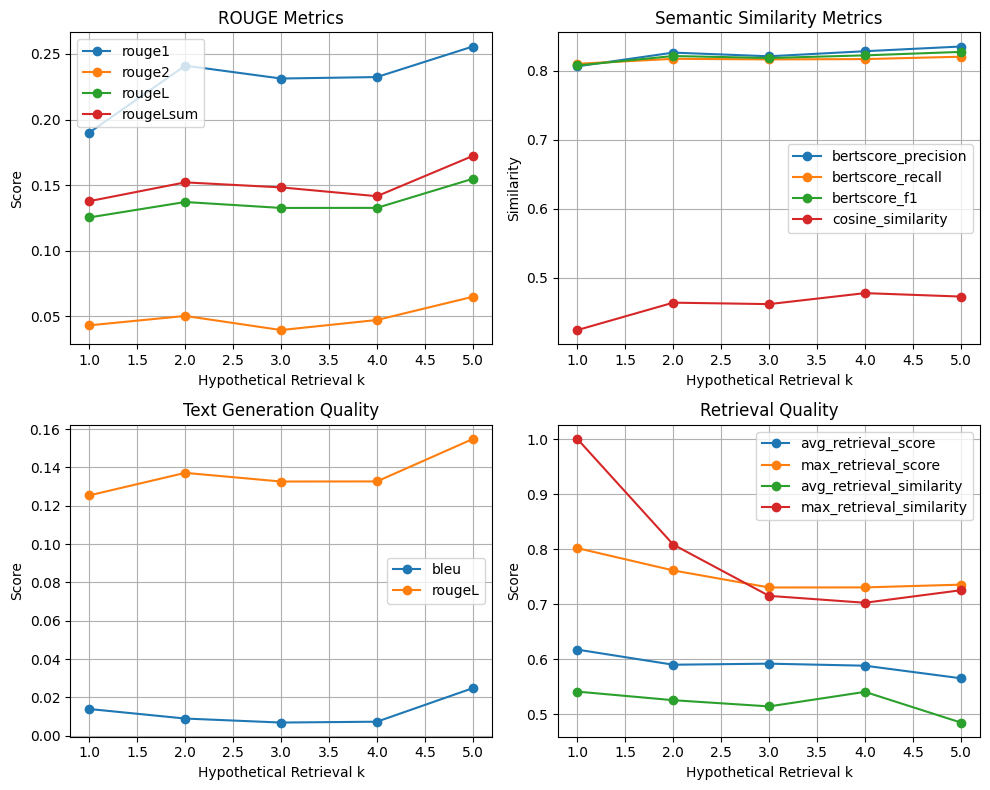

In [18]:
visualizeMetrics(hydeRagResults, paramValues=list(range(1, 6)), paramName='Hypothetical Retrieval k')

In [ ]:
with open('models/hydeRagResults.pkl', 'wb') as f:
    pickle.dump(hydeRagResults, f)

# Query Processing: 

#### Query Expansion

In [20]:
def qeRagEvaluation(eval_df,client,collection_name='corpus',colname='doc',k=3, num_expansions=3):
    import httpx

    metrics=[]
    for i,row in eval_df.iterrows():
        test_query=row['user_input']
        expPrompt = f"""Generate {num_expansions} different ways to ask this question:

        Original question: {test_query}

        Variations:
        1."""
        resp = httpx.post("http://localhost:8001/generate",json={"prompt": expPrompt, "max_tokens": 150, "temperature": 0.3},timeout=120.0)
        expDoc=""
        if resp.status_code == 200:
            expDoc = resp.json()['text']
            expDoc = expDoc[len(expPrompt):]
            expansions = [test_query]
            lines = expDoc.split('\n')
            for line in lines:
                if '.' in line and len(line.split('.')[1].strip()) > 10:
                    expansions.append(line.split('.')[1].strip())
            all_results = []
            seen_ids = set()
            for exp in expansions[:num_expansions]:
                results = retrieveQueryEmbeddings(exp, client, collection_name, k=k, verbose=False)
                for point in results.points:
                    if point.id not in seen_ids:
                        seen_ids.add(point.id)
                        all_results.append(point)
            all_results.sort(key=lambda x: x.score, reverse=True)
            unique_results = all_results[:k]
        llmResponse=llmRespose(query_results=unique_results, test_query=test_query, colname=colname, verbose=False)
        metric=evaluate_answer(generated_answer=str(llmResponse), ground_truth=row['reference'], query_results=unique_results, groundContext=row['retrieved_contexts'],colname=colname)
        metrics.append(metric)
        if (i+1)%10==0:
            print(f"Processed {i+1} / {len(eval_df)}")
    return pd.DataFrame(metrics)

In [8]:
with open('models/qeRagResults1.pkl', 'rb') as f:
    qeRagResults1 = pickle.load(f)

In [ ]:
qeRagResults1=[None] * 5
for i in range(1,6):
    qeRagResults1[i-1]=qeRagEvaluation(eval_df=eval,client=client,k=i, num_expansions=3)

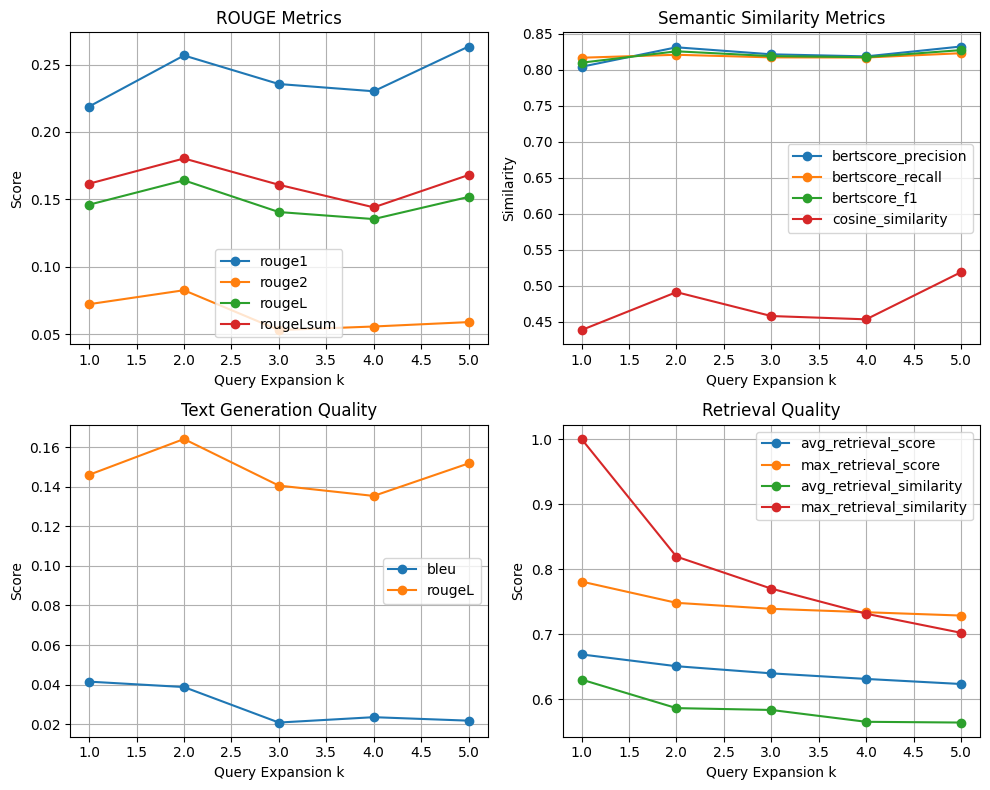

In [23]:
visualizeMetrics(qeRagResults1, paramValues=list(range(1, 6)), paramName='Query Expansion k')

In [9]:
with open('models/qeRagResults2.pkl', 'rb') as f:
    qeRagResults2 = pickle.load(f)

In [ ]:
qeRagResults2=[None] * 5
for i in range(2,7):
    qeRagResults2[i-2]=qeRagEvaluation(eval_df=eval,client=client,k=2, num_expansions=i)

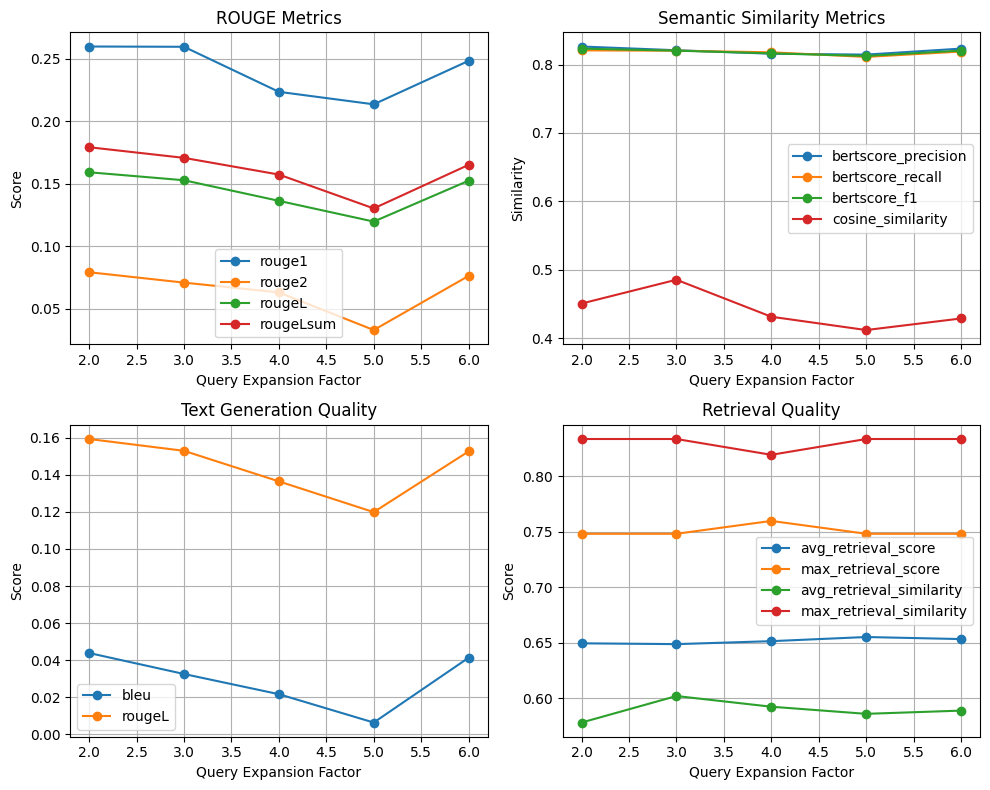

In [26]:
visualizeMetrics(qeRagResults2, paramValues=list(range(2, 7)), paramName='Query Expansion Factor')

In [ ]:
with open('models/qeRagResults1.pkl', 'wb') as f:
    pickle.dump(qeRagResults1, f)

with open('models/qeRagResults2.pkl', 'wb') as f:
    pickle.dump(qeRagResults2, f)

# Iterative RAG

#### Multi-Step Retrieval

In [27]:
def msIgRagEvaluation(eval_df,client,collection_name='corpus',colname='doc',k=3, kStep=2, nSteps=2):
    import httpx

    metrics=[]
    for i,row in eval_df.iterrows():
        test_query=row['user_input']
        all_contexts = []
        current_query = test_query
        results = retrieveQueryEmbeddings(current_query, client, collection_name, k=k, verbose=False)
        for r in results.points:
            context_value = r.payload[colname]
            if isinstance(context_value, list):
                all_contexts.append(" ".join(str(item) for item in context_value))
            else:
                all_contexts.append(str(context_value))
        for step in range(nSteps):
            if step < nSteps - 1:
                intermediate_context = " ".join(all_contexts[-kStep:]) 
                intermediate_prompt = f"""Based on this context: {intermediate_context}

                What additional follow-up questions would help better answer: {test_query}

                Follow-up question:"""
                resp = httpx.post("http://localhost:8001/generate",json={"prompt": intermediate_prompt, "max_tokens": 50, "temperature": 0.5},timeout=120.0)
            
                if resp.status_code == 200:
                    follow_up = resp.json()['text'].strip()
                    follow_up = follow_up[len(intermediate_prompt):]
                    current_query = follow_up
                    step_results = retrieveQueryEmbeddings(current_query, client, collection_name, k=kStep, verbose=False)
                    for r in step_results.points:
                        context_value = r.payload[colname]
                        if isinstance(context_value, list):
                            all_contexts.append(" ".join(str(item) for item in context_value))
                        else:
                            all_contexts.append(str(context_value))
                    results = step_results
        results=retrieveQueryEmbeddings(" ".join(all_contexts), client, collection_name, k=k, verbose=False)
        error= True
        while error is True:
            try:
                llmResponse=llmRespose(query_results=results, test_query=test_query, colname=colname, verbose=False)
                metric=evaluate_answer(generated_answer=llmResponse, ground_truth=row['reference'], query_results=results, groundContext=row['retrieved_contexts'],colname=colname)
                metrics.append(metric)
                error=False
            except Exception as e:
                print(f"Error processing row {i}: {e}")
        if (i+1)%10==0:
            print(f"Processed {i+1} / {len(eval_df)}")
    return pd.DataFrame(metrics)

In [10]:
with open('models/msIgRagResults1.pkl', 'rb') as f:
    msIgRagResults1 = pickle.load(f)

In [ ]:
msIgRagResults1=[None] * 5
for i in range(1,6):
    msIgRagResults1[i-1]=msIgRagEvaluation(eval_df=eval,client=client,k=i, kStep=2, nSteps=2)

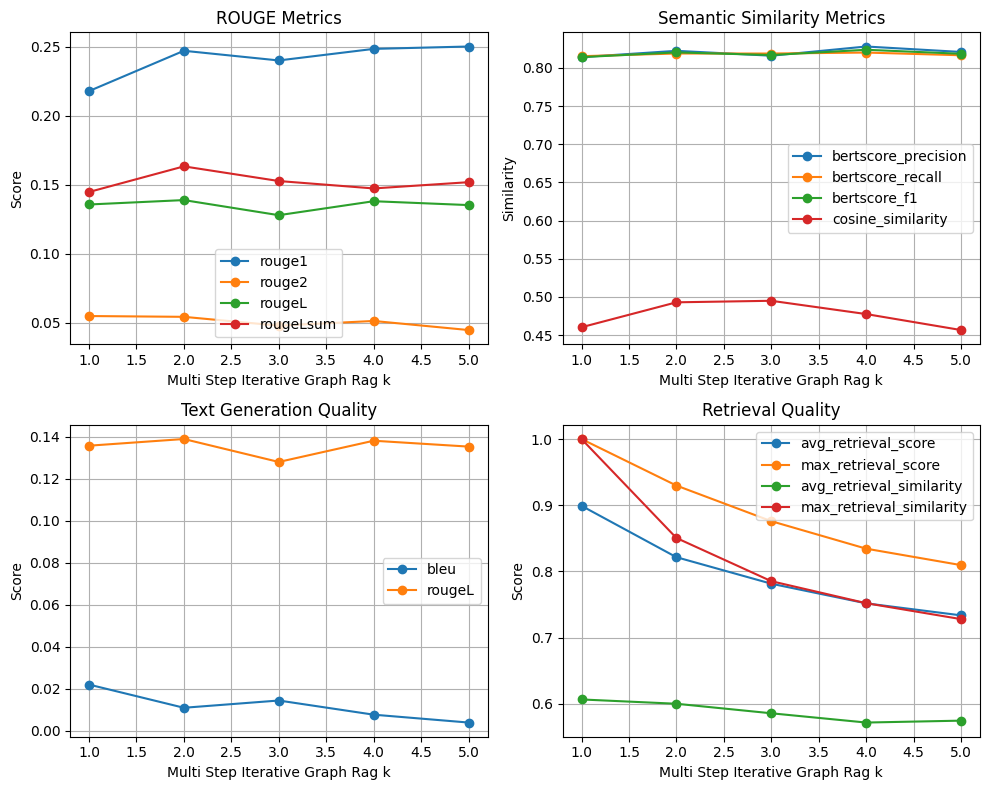

In [30]:
visualizeMetrics(msIgRagResults1, paramValues=list(range(1, 6)), paramName='Multi Step Iterative Graph Rag k')

In [11]:
with open('models/msIgRagResults2.pkl', 'rb') as f:
    msIgRagResults2 = pickle.load(f)

In [ ]:
msIgRagResults2=[None] * 5
for i in range(1,6):
    msIgRagResults2[i-1]=msIgRagEvaluation(eval_df=eval,client=client,k=2, kStep=i, nSteps=2)

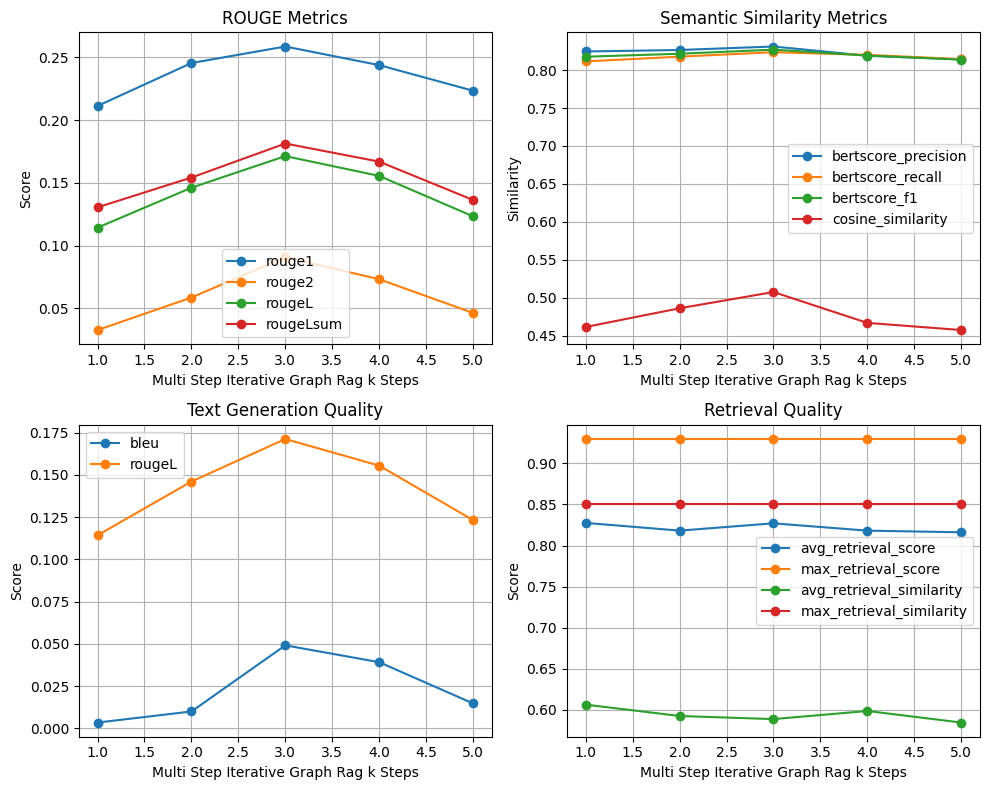

In [33]:
visualizeMetrics(msIgRagResults2, paramValues=list(range(1, 6)), paramName='Multi Step Iterative Graph Rag k Steps')

In [12]:
with open('models/msIgRagResults3.pkl', 'rb') as f:
    msIgRagResults3 = pickle.load(f)

In [ ]:
msIgRagResults3=[None] * 5
for i in range(1,6):
    msIgRagResults3[i-1]=msIgRagEvaluation(eval_df=eval,client=client,k=2, kStep=3, nSteps=i)

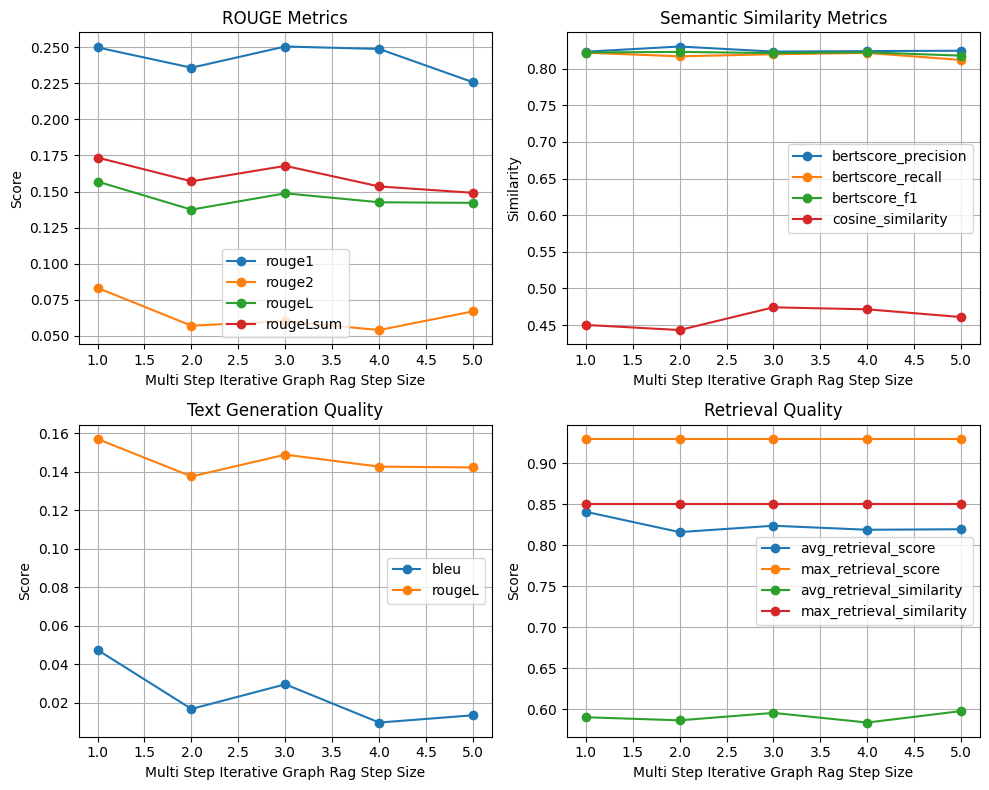

In [36]:
visualizeMetrics(msIgRagResults3, paramValues=list(range(1, 6)), paramName='Multi Step Iterative Graph Rag Step Size')

In [ ]:
with open('models/msIgRagResults1.pkl', 'wb') as f:
    pickle.dump(msIgRagResults1, f)

with open('models/msIgRagResults2.pkl', 'wb') as f:
    pickle.dump(msIgRagResults2, f)

with open('models/msIgRagResults3.pkl', 'wb') as f:
    pickle.dump(msIgRagResults3, f)

# Analysis Phase

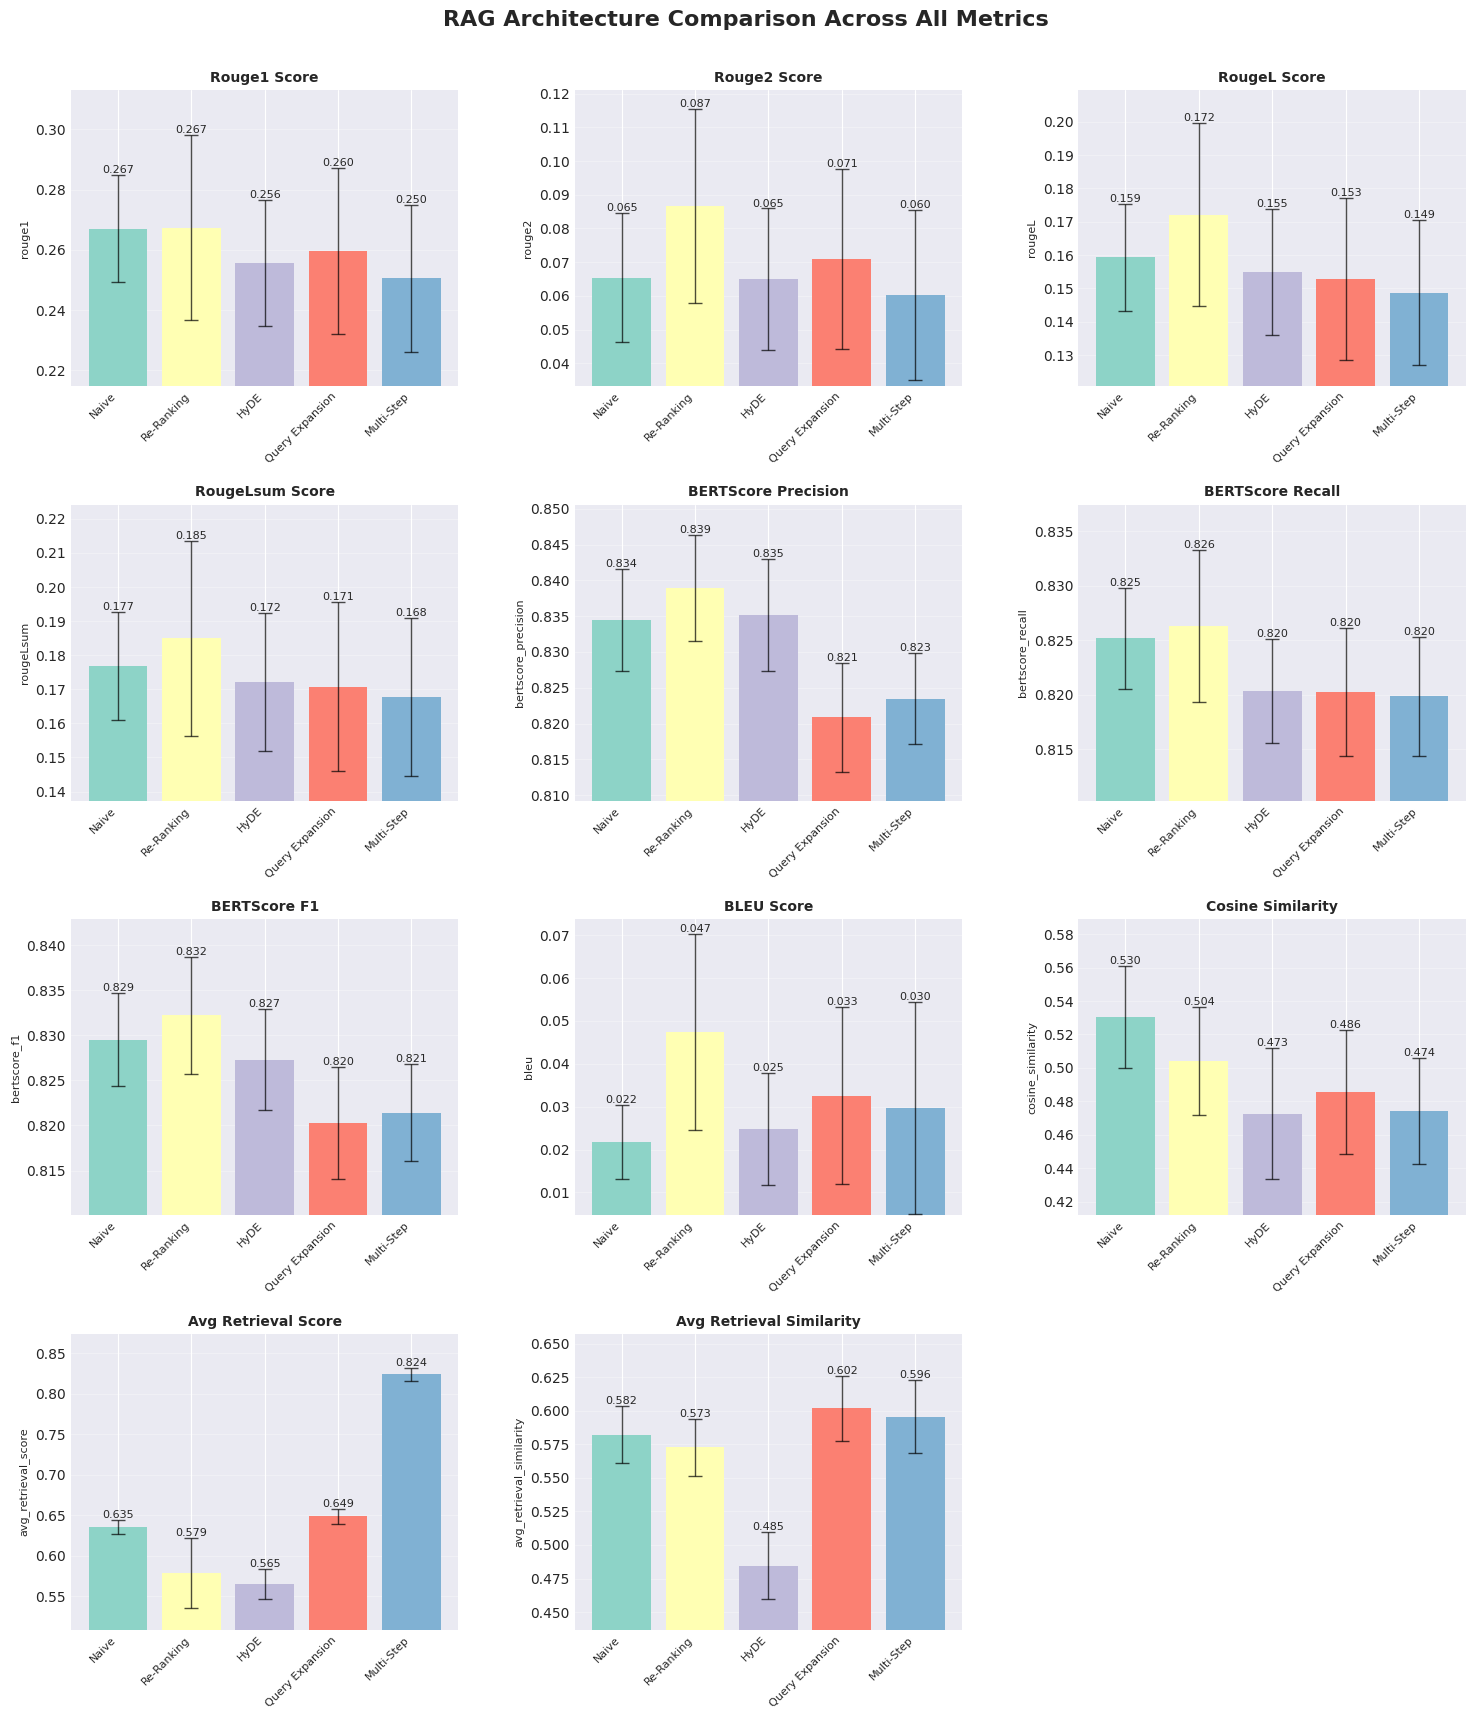

In [100]:
dt=compareViz(["Naive", "Re-Ranking", "HyDE", "Query Expansion", "Multi-Step"],
           [naiveRagResults[2], reRankingRagResults2[2], hydeRagResults[4], qeRagResults2[1], msIgRagResults3[2]], error_type='sem')

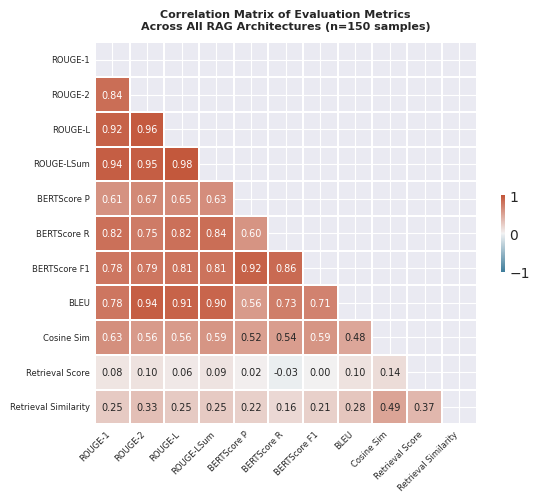

In [136]:
corrMatrix({"Naive RAG": naiveRagResults[2],"Re-Ranking RAG": reRankingRagResults2[2],"HyDE RAG": hydeRagResults[4],"Query Expansion RAG": qeRagResults2[1],"Multi-Step RAG": msIgRagResults3[2]})